In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import rasterio.transform
import pyproj

In [2]:
with rasterio.open("../data/gully-pass3/Dutch Bill Creek-pass3-graph.tif") as file:
    graph = file.read(1)
    index_to_crs = file.transform
    crs_to_lonlat = pyproj.Transformer.from_crs(file.crs, "EPSG:4326", always_xy=True)
    def index_to_lonlat(i, j):
        return crs_to_lonlat.transform(*rasterio.transform.xy(index_to_crs, i, j))

In [3]:
# bitmasks for 8-connected neighborhood directions
connected_NW = np.uint8(0b00000001)
connected_N  = np.uint8(0b00000010)
connected_NE = np.uint8(0b00000100)
connected_W  = np.uint8(0b00001000)
connected_E  = np.uint8(0b00010000)
connected_SW = np.uint8(0b00100000)
connected_S  = np.uint8(0b01000000)
connected_SE = np.uint8(0b10000000)

In [4]:
def possible_steps(i1, j1, i2, j2):
    out = []
    if graph[i2, j2] & connected_NW:
        i3, j3 = i2 - 1, j2 - 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_N:
        i3, j3 = i2 - 1, j2
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_NE:
        i3, j3 = i2 - 1, j2 + 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_W:
        i3, j3 = i2, j2 - 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_E:
        i3, j3 = i2, j2 + 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_SW:
        i3, j3 = i2 + 1, j2 - 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_S:
        i3, j3 = i2 + 1, j2
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_SE:
        i3, j3 = i2 + 1, j2 + 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    return out

In [5]:
def possible_extensions(path):
    i1, j1 = path[-2]
    i2, j2 = path[-1]

    next_steps = possible_steps(i1, j1, i2, j2)

    if len(next_steps) == 0:
        return [path]

    elif len(next_steps) == 1:
        i3, j3 = next_steps[0]
        path.append((i3, j3))
        if num_connections[i3, j3] == 2:
            return possible_extensions(path)
        else:
            return [path]

    else:
        out = []
        for i3, j3 in next_steps:
            new_path = list(path)
            new_path.append((i3, j3))
            if num_connections[i3, j3] == 2:
                out.extend(possible_extensions(new_path))
            else:
                out.append(new_path)
        return out

def possible_paths(i1, j1):
    out = []
    for i2, j2 in possible_steps(i1, j1, i1, j1):
        path = [(i1, j1), (i1, j2)]
        out.extend(possible_extensions(path))
    return out

In [6]:
num_connections = np.unpackbits(graph).reshape(graph.shape + (8,)).sum(axis=-1)

In [7]:
path_seeds = np.concatenate([
    np.dstack(np.nonzero(num_connections == 1))[0],
    np.dstack(np.nonzero(num_connections >= 3))[0],
], axis=0)

In [8]:
%%time

paths1 = []
for i1, j1 in path_seeds:
    paths1.extend(possible_paths(i1, j1))

CPU times: user 525 ms, sys: 45.9 ms, total: 571 ms
Wall time: 571 ms


In [9]:
%%time

paths2 = []
for i1, j1 in path_seeds:
    path = []
    path.append([i1, j1])
    i2, j2 = possible_steps(i1, j1, i1, j1)[0]
    path.append([i2, j2])
    while num_connections[i2, j2] == 2:
        i3, j3 = possible_steps(i1, j1, i2, j2)[0]
        path.append([i3, j3])
        i1, j1 = i2, j2
        i2, j2 = i3, j3
    paths2.append(path)

CPU times: user 801 ms, sys: 18 ms, total: 819 ms
Wall time: 818 ms


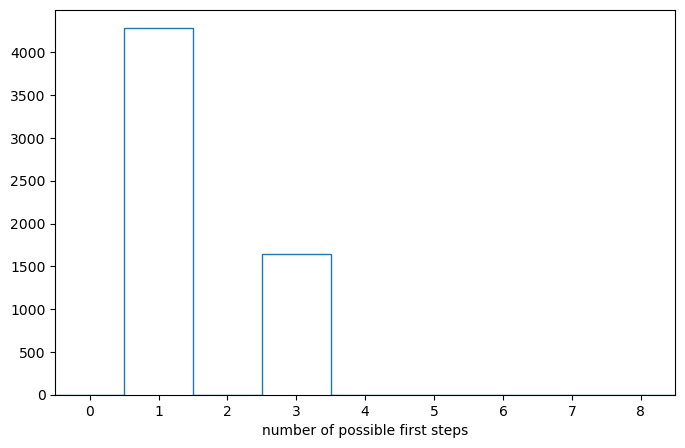

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist([len(possible_steps(i1, j1, i1, j1)) for i1, j1 in path_seeds], bins=9, range=(-0.5, 8.5), histtype="step")

ax.set_xticks(range(9))
ax.set_xlim(-0.5, 8.5)
ax.set_xlabel("number of possible first steps")

None

In [23]:
%%time

paths3 = []
for i1, j1 in path_seeds:
    seen = set()
    for i2, j2 in possible_steps(i1, j1, i1, j1):
        for i3, j3 in possible_steps(i1, j1, i2, j2):
            if (i3, j3) not in seen:
                seen.add((i3, j3))
                path = [(i1, j1), (i2, j2), (i3, j3)]
                while num_connections[path[-1][0], path[-1][1]] == 2:
                    path.append(possible_steps(path[-2][0], path[-2][1], path[-1][0], path[-1][1])[0])
                paths3.append(path)

CPU times: user 1.06 s, sys: 35.9 ms, total: 1.09 s
Wall time: 1.09 s


In [24]:
len(paths1), len(paths2), len(paths3)

(11382, 5929, 10284)

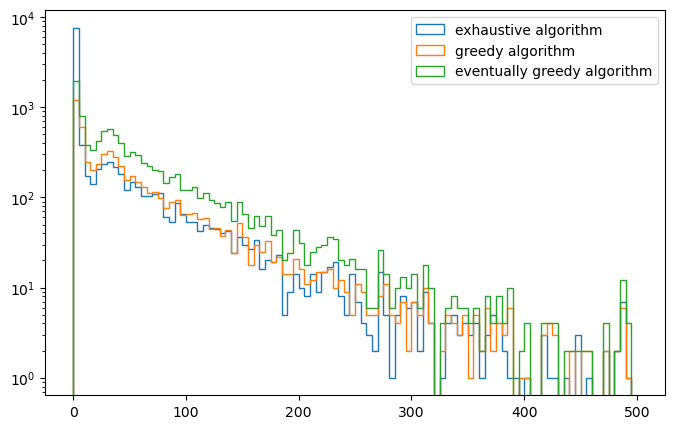

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist([len(x) for x in paths1], bins=100, range=(0, 500), histtype="step", label="exhaustive algorithm")
ax.hist([len(x) for x in paths2], bins=100, range=(0, 500), histtype="step", label="greedy algorithm")
ax.hist([len(x) for x in paths3], bins=100, range=(0, 500), histtype="step", label="eventually greedy algorithm")
ax.legend()
ax.set_yscale("log")

None

In [28]:
cmap = mpl.colors.LinearSegmentedColormap.from_list("white_magenta", ["white", "magenta"])

In [32]:
darker = (
    graph[0:4000, 0:4000] |
    graph[0:4000, 1:4001] |
    graph[0:4000, 2:4002] |
    graph[1:4001, 0:4000] |
    graph[1:4001, 1:4001] |
    graph[1:4001, 2:4002] |
    graph[2:4002, 0:4000] |
    graph[2:4002, 1:4001] |
    graph[2:4002, 2:4002] != 0
)

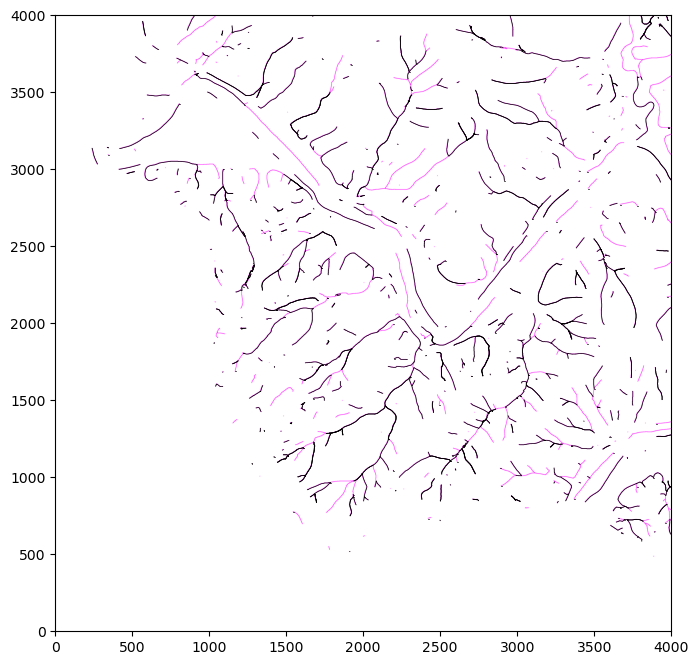

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(darker, vmin=0, vmax=1, cmap=cmap)

for path in paths1:
    ax.plot([j for i, j in path], [i for i, j in path], linewidth=0.5, c="black")

ax.set_xlim(0, 4000)
ax.set_ylim(0, 4000)

None

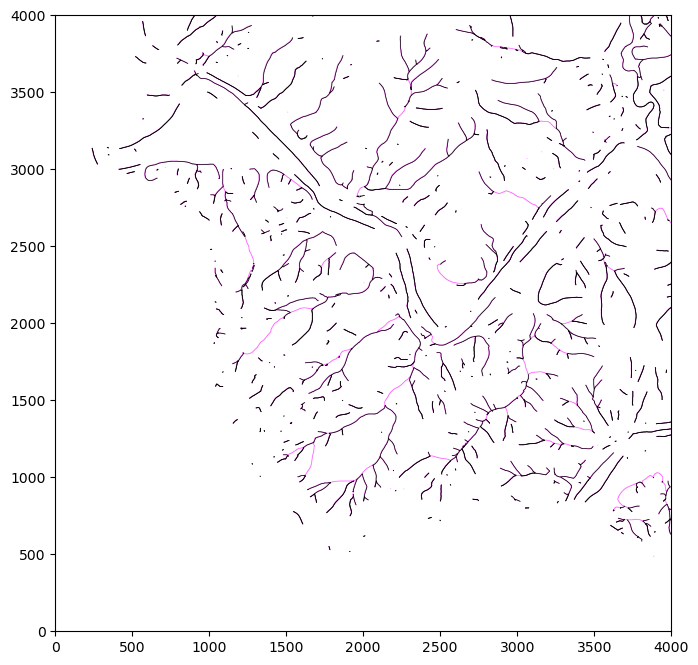

In [35]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(darker, vmin=0, vmax=1, cmap=cmap)

for path in paths2:
    ax.plot([j for i, j in path], [i for i, j in path], linewidth=0.5, c="black")

ax.set_xlim(0, 4000)
ax.set_ylim(0, 4000)

None

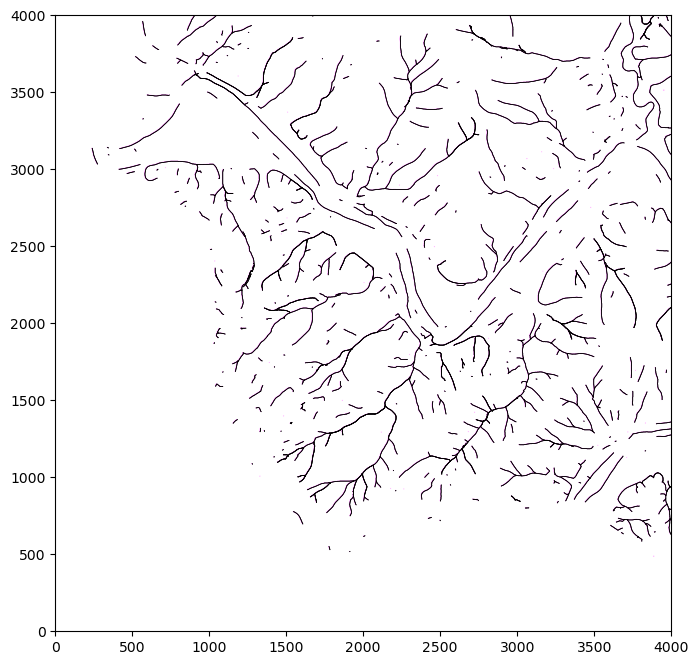

In [36]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(darker, vmin=0, vmax=1, cmap=cmap)

for path in paths3:
    ax.plot([j for i, j in path], [i for i, j in path], linewidth=0.5, c="black")

ax.set_xlim(0, 4000)
ax.set_ylim(0, 4000)

None